# Exercise 1: Classification with US Airline Sentiment Tweets

## Στόχος
Ταξινόμηση tweets σε 3 κατηγορίες συναισθήματος (**Negative**, **Neutral**, **Positive**) χρησιμοποιωντας:
- Προεπεξεργασία κειμένου (NLP Preprocessing)
- Vectorization με **TF-IDF** και **Word2Vec**
- Feed-forward Neural Network (**ANN/MLP**) σε **PyTorch**

---

## Εισαγωγή Βιβλιοθηκών (Imports)

Βάζουμε ολες τις βιβλιοθηκες που θα χρειαστούμε. Βασικά pandas για τα δεδομένα, nltk/sklearn για NLP και vectorization, torch για το νευρωνικό, και gensim για Word2Vec/FastText.

In [71]:
# Εγκατάσταση βιβλιοθηκών που χρειαζόμαστε
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu -q
!pip install gensim nltk scikit-learn matplotlib seaborn wordcloud -q


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\YQ289MZ\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\YQ289MZ\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

## Φόρτωση Δεδομένων & Πρώτη Ματιά

Φορτώνουμε το CSV και κοιτάμε τι εχουμε. Πόσες γραμμές, τι στήλες, αν υπάρχουν κενά κτλ. Βασικά θέλουμε μια γενική εικόνα πριν αρχίσουμε.

In [ ]:
# Φόρτωση δεδομένων
df = pd.read_csv('Tweets.csv')

print(f"Μέγεθος dataset: {df.shape[0]} γραμμές x {df.shape[1]} στήλες")
print(f"\nΣτήλες: {list(df.columns)}")
print(f"\nΠρώτα 3 tweets: ")
df.head(3)

Μέγεθος dataset: 14640 γραμμές x 15 στήλες

Στήλες: ['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count', 'text', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone']

Πρώτα 3 tweets: 


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)


In [ ]:
# κρατάμε μονο text, sentiment και airline (τα υπόλοιπα δεν χρειάζονται)
df = df[['text', 'airline_sentiment', 'airline']].copy()

# τσεκ για nulls
print("Κενές τιμές ανά στήλη:")
print(df.isnull().sum())
print(f"\nΣυνολικές γραμμές: {len(df)}")

print(f"\nΤύποι δεδομένων:")
print(df.dtypes)

Κενές τιμές ανά στήλη:
text                 0
airline_sentiment    0
airline              0
dtype: int64

Συνολικές γραμμές: 14640

Τύποι δεδομένων:
text                 str
airline_sentiment    str
airline              str
dtype: object


## EDA (Exploratory Data Analysis)

Πρώτα κοιτάμε τα δεδομένα για να δούμε τι εχουμε. Κυρίως με ενδιέφερε αν οι κλάσεις είναι balanced και ποιες λέξεις εμφανίζονται πιο συχνά σε κάθε sentiment.

Κατανομή sentiment:
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

Ποσοστά:
airline_sentiment
negative    62.7
neutral     21.2
positive    16.1
Name: proportion, dtype: float64


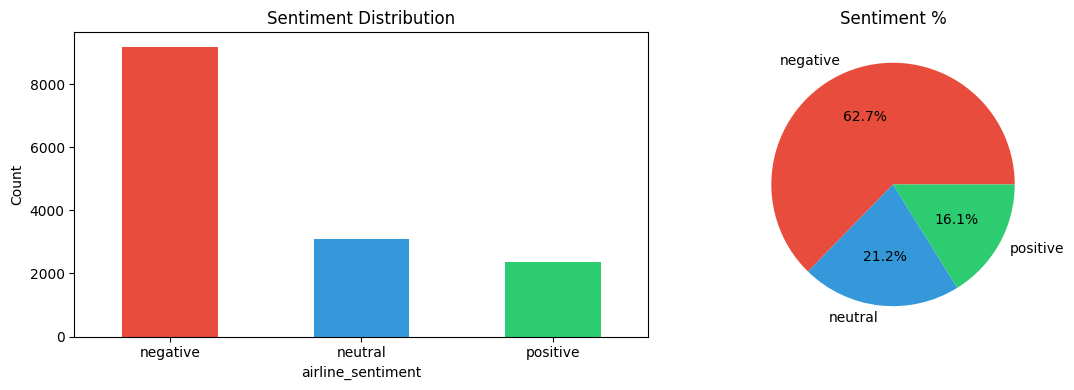

In [75]:
# κατανομή κλάσεων - θέλω να δω αν ειναι balanced
print("Κατανομή sentiment:")
print(df['airline_sentiment'].value_counts())
print(f"\nΠοσοστά:")
print(df['airline_sentiment'].value_counts(normalize=True).round(3) * 100)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['airline_sentiment'].value_counts().plot(kind='bar', ax=axes[0], color=['#e74c3c', '#3498db', '#2ecc71'])
axes[0].set_title('Sentiment Distribution')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

df['airline_sentiment'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                                             colors=['#e74c3c', '#3498db', '#2ecc71'])
axes[1].set_ylabel('')
axes[1].set_title('Sentiment %')

plt.tight_layout()
plt.show()

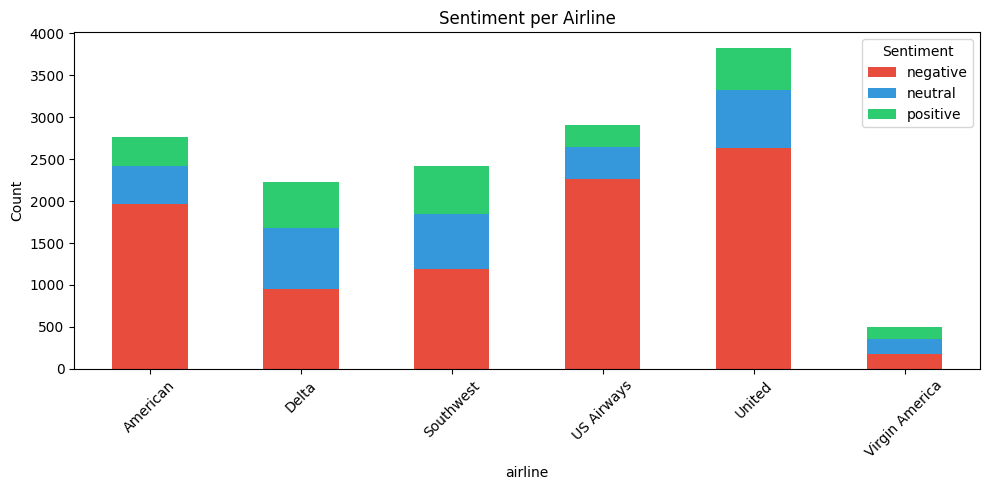


Tweets ανά airline:
airline
United            3822
US Airways        2913
American          2759
Southwest         2420
Delta             2222
Virgin America     504
Name: count, dtype: int64


In [76]:
# sentiment ανά airline
ct = pd.crosstab(df['airline'], df['airline_sentiment'])
ct.plot(kind='bar', stacked=True, figsize=(10, 5), color=['#e74c3c', '#3498db', '#2ecc71'])
plt.title('Sentiment per Airline')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

print("\nTweets ανά airline:")
print(df['airline'].value_counts())

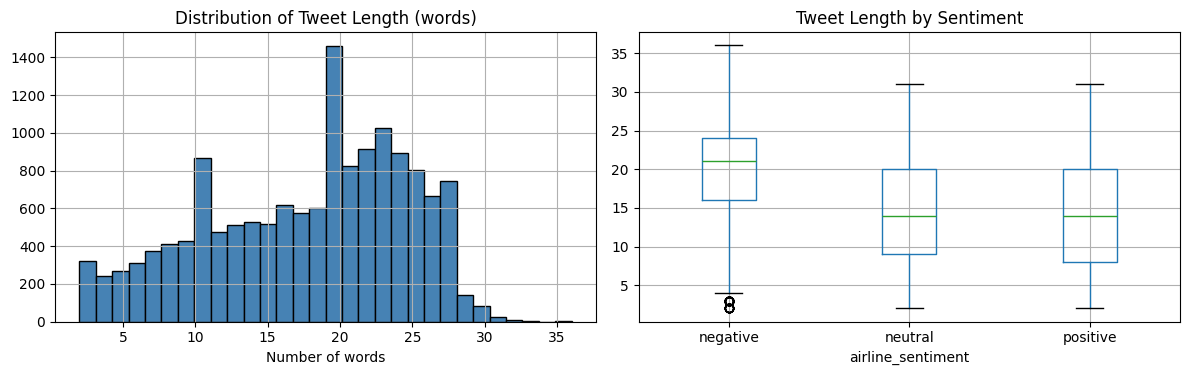

Μέσο μήκος tweet: 17.7 λέξεις
Min: 2, Max: 36


In [77]:
# μήκος tweets σε λεξεις
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['word_count'].hist(bins=30, ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Tweet Length (words)')
axes[0].set_xlabel('Number of words')

df.boxplot(column='word_count', by='airline_sentiment', ax=axes[1])
axes[1].set_title('Tweet Length by Sentiment')
plt.suptitle('')

plt.tight_layout()
plt.show()

print(f"Μέσο μήκος tweet: {df['word_count'].mean():.1f} λέξεις")
print(f"Min: {df['word_count'].min()}, Max: {df['word_count'].max()}")

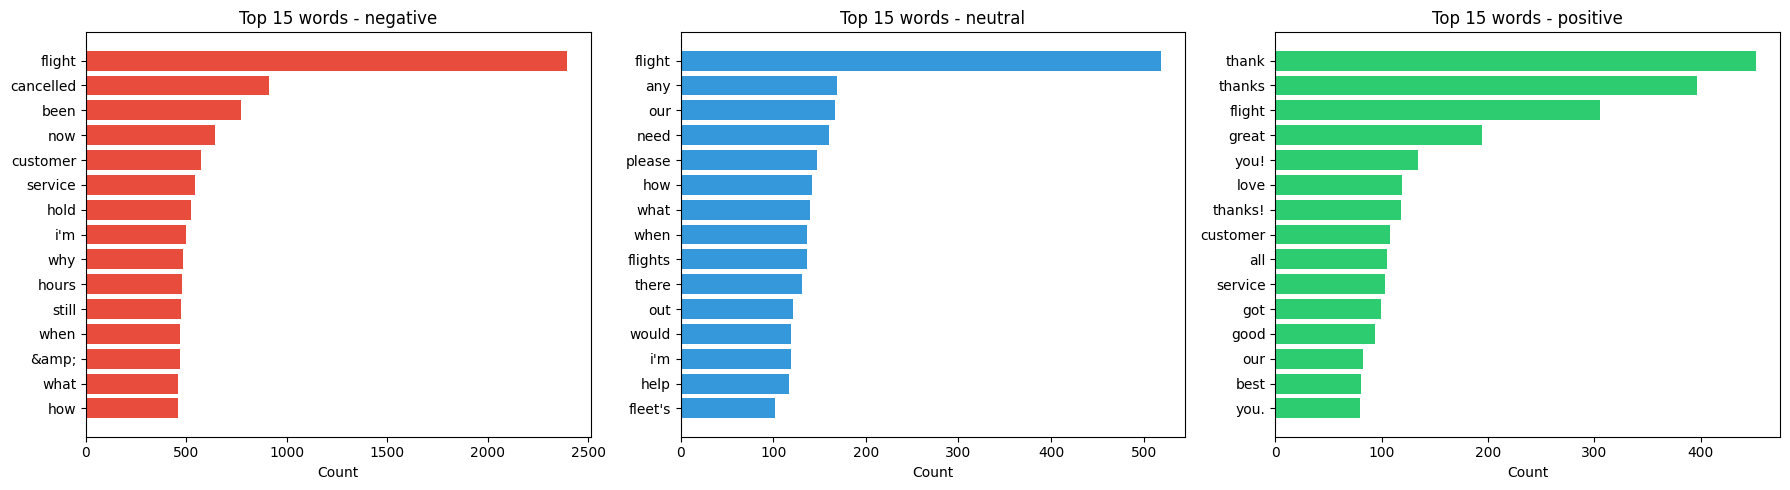

In [78]:
# top 15 λέξεις ανά sentiment (φιλτράρω @mentions και κοινά stopwords)
from collections import Counter

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, sentiment in enumerate(['negative', 'neutral', 'positive']):
    texts = df[df['airline_sentiment'] == sentiment]['text']
    all_words = ' '.join(texts).lower().split()
    all_words = [w for w in all_words if not w.startswith('@') and len(w) > 2 
                 and w not in ['the', 'and', 'for', 'you', 'was', 'are', 'that', 
                               'has', 'have', 'not', 'but', 'with', 'this', 'they',
                               'from', 'will', 'can', 'just', 'get', 'your', 'http']]
    
    word_counts = Counter(all_words).most_common(15)
    words, counts = zip(*word_counts)
    
    colors = {'negative': '#e74c3c', 'neutral': '#3498db', 'positive': '#2ecc71'}
    axes[idx].barh(range(len(words)), counts, color=colors[sentiment])
    axes[idx].set_yticks(range(len(words)))
    axes[idx].set_yticklabels(words)
    axes[idx].invert_yaxis()
    axes[idx].set_title(f'Top 15 words - {sentiment}')
    axes[idx].set_xlabel('Count')

plt.tight_layout()
plt.show()

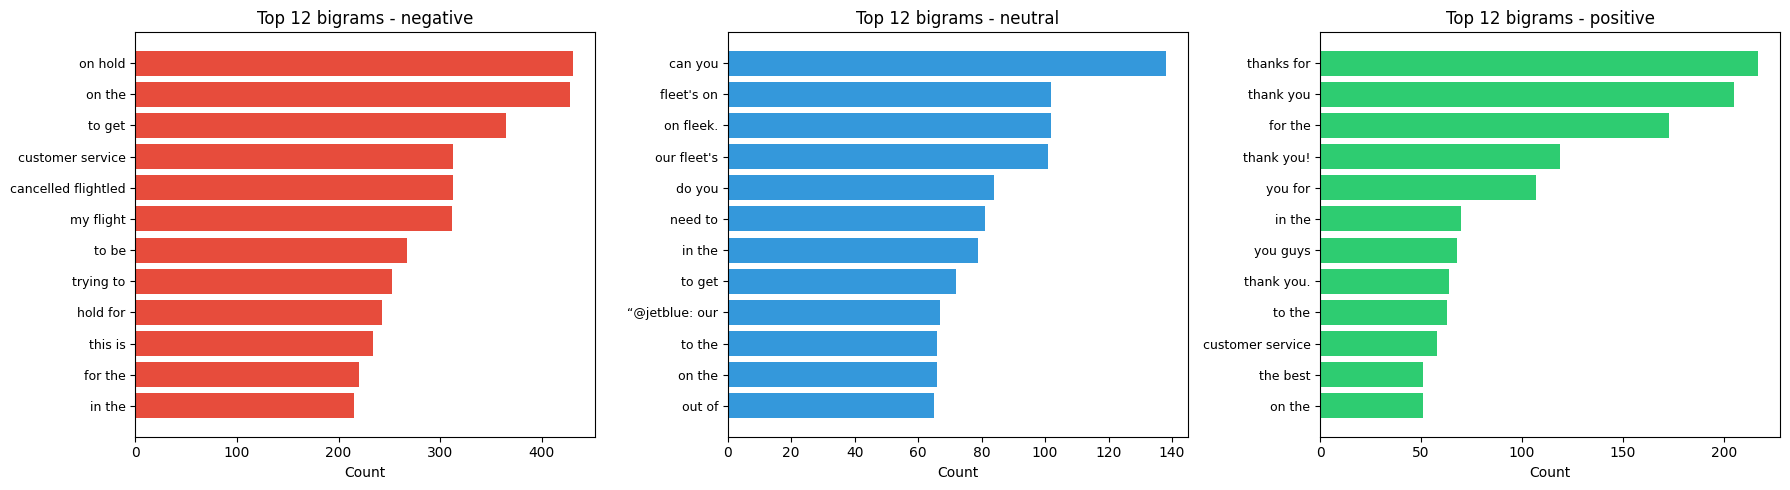

Παρατήρηση: Τα bigrams αποκαλύπτουν patterns:
  Negative: 'customer service', 'flight cancelled', 'on hold'
  Positive: 'thank you', 'great service'
  Neutral: 'to get', 'going to'


In [79]:
# bigram analysis - ζεύγη λέξεων που εμφανίζονται μαζί
from itertools import islice

def get_bigrams(text):
    words = text.lower().split()
    words = [w for w in words if not w.startswith('@') and not w.startswith('http') and len(w) > 1]
    return list(zip(words[:-1], words[1:]))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, sentiment in enumerate(['negative', 'neutral', 'positive']):
    texts = df[df['airline_sentiment'] == sentiment]['text']
    
    all_bigrams = []
    for text in texts:
        all_bigrams.extend(get_bigrams(text))
    
    bigram_counts = Counter(all_bigrams).most_common(12)
    bigram_labels = [f"{b[0]} {b[1]}" for b, c in bigram_counts]
    bigram_values = [c for b, c in bigram_counts]
    
    colors = {'negative': '#e74c3c', 'neutral': '#3498db', 'positive': '#2ecc71'}
    axes[idx].barh(range(len(bigram_labels)), bigram_values, color=colors[sentiment])
    axes[idx].set_yticks(range(len(bigram_labels)))
    axes[idx].set_yticklabels(bigram_labels, fontsize=9)
    axes[idx].invert_yaxis()
    axes[idx].set_title(f'Top 12 bigrams - {sentiment}')
    axes[idx].set_xlabel('Count')

plt.tight_layout()
plt.show()

# τα bigrams δειχνουν ξεκάθαρα patterns
print("Negative: 'customer service', 'flight cancelled', 'on hold'")
print("Positive: 'thank you', 'great service'")
print("Neutral: πιο γενικα, 'to get', 'going to' κτλ")

## Text Preprocessing (Καθαρισμός Κειμένου)

Τα tweets εχουν πολύ θόρυβο (@mentions, URLs, σημεία στίξης κτλ). Φτιάχνουμε function για καθαρισμό. Βασικά αφαιρούμε mentions, urls και stopwords, κρατάμε μονο τις "χρήσιμες" λέξεις.

In [80]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'@\w+', '', text)                 # βγάζω mentions
    text = re.sub(r'http\S+|www\S+', '', text)       # βγάζω urls
    text = re.sub(r'#(\w+)', r'\1', text)            # κρατάω τη λέξη του hashtag
    text = re.sub(r'[^a-z\s]', '', text)             # μονο γράμματα
    text = re.sub(r'\s+', ' ', text).strip()
    
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in stop_words and len(w) > 1]
    
    return ' '.join(tokens)

# παράδειγμα πριν/μετα
print("Παράδειγμα:")
sample = df['text'].iloc[3]
print(f"ΠΡΙΝ:  {sample}")
print(f"ΜΕΤΑ:  {clean_text(sample)}")

\Παράδειγμα:
ΠΡΙΝ:  @VirginAmerica it's really aggressive to blast obnoxious "entertainment" in your guests' faces &amp; they have little recourse
ΜΕΤΑ:  really aggressive blast obnoxious entertainment guests faces amp little recourse


In [81]:
# εφαρμόζω τη clean_text σε ολα τα tweets
df['clean_text'] = df['text'].apply(clean_text)

# παρατήρησα ότι μερικά tweets μετά το cleaning γίνονται
# πολύ κοντά (1-2 λέξεις), αφαιρώ τα τελείως κενά
df = df[df['clean_text'].str.len() > 0].reset_index(drop=True)

print(f"Tweets μετά τον καθαρισμό: {len(df)}")
print(f"\nΠαραδείγματα:")
for i in range(3):
    print(f"  [{df['airline_sentiment'].iloc[i]:>8}] {df['clean_text'].iloc[i][:80]}")

Tweets μετά τον καθαρισμό: 14617

Παραδείγματα:
  [ neutral] said
  [positive] plus youve added commercials experience tacky
  [ neutral] didnt today must mean need take another trip


## Feature Extraction: TF-IDF & Word2Vec

Χρησιμοποιούμε δυο μεθοδους vectorization. TF-IDF που δίνει sparse vectors βάσει σπανιότητας λέξεων, και Word2Vec που δίνει dense vectors 100 αριθμών (παίρνουμε τον μέσο ορο ανά tweet). Τα δοκιμάζουμε και τα δυο για να δουμε ποιο δουλεύει καλύτερα.

In [ ]:
# labels σε αριθμούς
le = LabelEncoder()
df['label'] = le.fit_transform(df['airline_sentiment'])

print("Label mapping:")
for cls, num in zip(le.classes_, range(len(le.classes_))):
    print(f"  {cls} -> {num}")

# 80/20 split, stratify για να κρατήσει τα ποσοστά
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['clean_text'], df['label'], 
    test_size=0.2, random_state=42, stratify=df['label']
)

print(f"\nTrain: {len(X_train_text)} | Test: {len(X_test_text)}")

Label mapping:
  negative -> 0
  neutral -> 1
  positive -> 2

Train: 11693 | Test: 2924


In [83]:
# TF-IDF - δοκίμασα πρώτα max_features=10000 αλλά ήταν πολύ αργό
# με 5000 και bigrams (ngram 1-2) δουλεύει μια χαρά
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

# fit στο train, transform και στα δυο (αλλιώς data leakage)
X_train_tfidf = tfidf.fit_transform(X_train_text).toarray()
X_test_tfidf = tfidf.transform(X_test_text).toarray()

print(f"TF-IDF shape: Train {X_train_tfidf.shape}, Test {X_test_tfidf.shape}")

TF-IDF shape: Train (11693, 5000), Test (2924, 5000)
Κάθε tweet είναι τώρα ένα vector 5000 αριθμών


In [84]:
# Word2Vec - πρωτα tokenize, μετα train
train_tokenized = [text.split() for text in X_train_text]
test_tokenized = [text.split() for text in X_test_text]

# sg=1 -> skip-gram, window=5, min_count=2
w2v_model = Word2Vec(sentences=train_tokenized, vector_size=100, window=5, 
                     min_count=2, sg=1, workers=4, epochs=20)

print(f"Λεξιλόγιο Word2Vec: {len(w2v_model.wv)} λέξεις")
print(f"Vector size: {w2v_model.wv.vector_size}")

# sanity check
print(f"\nΠιο παρόμοιες λέξεις με 'bad':")
for word, score in w2v_model.wv.most_similar('bad', topn=5):
    print(f"  {word}: {score:.3f}")

Λεξιλόγιο Word2Vec: 4973 λέξεις
Vector size: 100

Πιο παρόμοιες λέξεις με 'bad':
  teams: 0.578
  affected: 0.576
  extreme: 0.572
  inexcusable: 0.560
  senseless: 0.558


In [85]:
# average word vectors ανα tweet (αν λεξη δεν υπάρχει -> skip)
def get_avg_w2v(tokens_list, model, vector_size):
    vectors = []
    for tokens in tokens_list:
        word_vecs = [model.wv[w] for w in tokens if w in model.wv]
        if word_vecs:
            vectors.append(np.mean(word_vecs, axis=0))
        else:
            vectors.append(np.zeros(vector_size))
    return np.array(vectors)

X_train_w2v = get_avg_w2v(train_tokenized, w2v_model, 100)
X_test_w2v = get_avg_w2v(test_tokenized, w2v_model, 100)

print(f"Word2Vec shape: Train {X_train_w2v.shape}, Test {X_test_w2v.shape}")

Word2Vec shape: Train (11693, 100), Test (2924, 100)
Κάθε tweet είναι τώρα ένα vector 100 αριθμών


In [86]:
# FastText - ιδια λογική με W2V αλλά χειρίζεται OOV λεξεις
# γιατι σπαει σε subwords (character n-grams)
from gensim.models import FastText

ft_model = FastText(sentences=train_tokenized, vector_size=100, window=5, 
                    min_count=2, sg=1, workers=4, epochs=20)

print(f"FastText vocabulary: {len(ft_model.wv)} λέξεις")

# δοκιμάζω typo λέξη - δουλεύει γιατι σπάει σε subwords
print(f"\nOOV test: 'cancelllled' -> shape: {ft_model.wv['cancelllled'].shape}")

# average vectors, ιδια λογική (δεν χρειάζεται if w in model.wv γιατι FastText παντα δίνει)
def get_avg_ft(tokens_list, model, vector_size):
    vectors = []
    for tokens in tokens_list:
        word_vecs = [model.wv[w] for w in tokens]
        if word_vecs:
            vectors.append(np.mean(word_vecs, axis=0))
        else:
            vectors.append(np.zeros(vector_size))
    return np.array(vectors)

X_train_ft = get_avg_ft(train_tokenized, ft_model, 100)
X_test_ft = get_avg_ft(test_tokenized, ft_model, 100)

print(f"\nFastText shape: Train {X_train_ft.shape}, Test {X_test_ft.shape}")

FastText vocabulary: 4973 λέξεις
Vector size: 100

Παράδειγμα OOV: vector για 'cancelllled' (typo) -> shape: (100,)

FastText shape: Train (11693, 100), Test (2924, 100)


## Baseline Models (Logistic Regression & SVM)

Πριν φτιάξουμε νευρωνικό ήθελα να δω πως πάνε τα κλασικά μοντέλα. Αν LR/SVM δίνουν ήδη καλά νούμερα, τοτε δεν αξίζει η πολυπλοκοτητα του ANN. Δοκιμάζω και τα 3 vectorizations.

*Σημείωση: Τα baseline δεν ζητούνται στην εκφώνηση, τα εβαλα για σύγκριση.*

In [ ]:
# Baseline: LR και SVM σε ολα τα vectorizations
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score

results = {}

vectorizations = {
    'TF-IDF': (X_train_tfidf, X_test_tfidf),
    'Word2Vec': (X_train_w2v, X_test_w2v),
    'FastText': (X_train_ft, X_test_ft)
}

for vec_name, (X_tr, X_te) in vectorizations.items():
    
    lr = LogisticRegression(max_iter=1000, class_weight='balanced', C=1.0)
    lr.fit(X_tr, y_train)
    lr_preds = lr.predict(X_te)
    lr_acc = accuracy_score(y_test, lr_preds)
    lr_f1 = f1_score(y_test, lr_preds, average='macro')
    results[f'LR + {vec_name}'] = {'accuracy': lr_acc, 'macro_f1': lr_f1}
    
    svm = LinearSVC(max_iter=2000, class_weight='balanced', C=1.0)
    svm.fit(X_tr, y_train)
    svm_preds = svm.predict(X_te)
    svm_acc = accuracy_score(y_test, svm_preds)
    svm_f1 = f1_score(y_test, svm_preds, average='macro')
    results[f'SVM + {vec_name}'] = {'accuracy': svm_acc, 'macro_f1': svm_f1}

print("Baseline Results:")
print(f"{'Model':<25} {'Accuracy':>10} {'Macro F1':>10}")
print("-" * 47)
for model_name, scores in results.items():
    print(f"{model_name:<25} {scores['accuracy']:>10.4f} {scores['macro_f1']:>10.4f}")
    
# ηδη βλέπω ότι LR+TF-IDF παει πολυ καλα...
print(f"\nΑς δούμε αν το ANN θα τα ξεπεράσει.")

Baseline Results:
Model                       Accuracy   Macro F1
-----------------------------------------------
LR + TF-IDF                   0.7538     0.7080
SVM + TF-IDF                  0.7654     0.7054
LR + Word2Vec                 0.7052     0.6493
SVM + Word2Vec                0.7442     0.6639
LR + FastText                 0.7199     0.6655
SVM + FastText                0.7534     0.6770

Τα baseline models μας δίνουν μια βάση σύγκρισης.
Αν το ANN δεν τα ξεπεράσει, τότε δεν αξίζει η πολυπλοκότητά του.


## Κατασκευή ANN (Neural Network) σε PyTorch

Φτιάχνουμε δυο MLP αρχιτεκτονικές. Μια μεγαλύτερη (256->128->64) για W2V/FastText που εχουν 100 features, και μια μικρότερη (128->64) για TF-IDF που εχει 5000 features και κάνει πιο εύκολα overfit.

Βάζουμε BatchNorm γιατί βοηθάει στη σύγκλιση, Dropout για regularization, και class weights στο loss γιατι εχουμε imbalanced data.

In [ ]:
# LargeANN: 256->128->64 (για W2V/FastText, 100 features)
class SentimentANN(nn.Module):
    def __init__(self, input_dim, num_classes=3):
        super(SentimentANN, self).__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),          # batchnorm βοηθάει στη σύγκλιση
            nn.Dropout(0.3),
            
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),
            
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),              # λιγοτερο dropout στο τελος
            
            nn.Linear(64, num_classes)
        )
    
    def forward(self, x):
        return self.network(x)

# SmallANN: 128->64 (για TF-IDF, 5000 features - μικροτερο για να μην κάνει overfit)
class SmallANN(nn.Module):
    def __init__(self, input_dim, num_classes=3):
        super(SmallANN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        return self.network(x)

print("Αρχιτεκτονικές:")
print("\nLargeANN (256->128->64):")
print(SentimentANN(input_dim=100))
print("\nSmallANN (128->64):")
print(SmallANN(input_dim=5000))

Αρχιτεκτονικές μοντέλων:

LargeANN (256→128→64) - για Word2Vec/FastText:
SentimentANN(
  (network): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): ReLU()
    (10): Dropout(p=0.2, inplace=False)
    (11): Linear(in_features=64, out_features=3, bias=True)
  )
)

SmallANN (128→64) - για TF-IDF:
SmallANN(
  (network): Sequential(
    (0): Linear(in_features=5000, out_features=128, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear

In [ ]:
# training function - δέχεται model_class για να τρέχω και SmallANN και LargeANN
def train_model(X_train, X_test, y_train, y_test, model_name="Model", 
                epochs=50, batch_size=64, lr=0.001, patience=5, model_class=SentimentANN):
    
    X_tr = torch.FloatTensor(X_train)
    X_te = torch.FloatTensor(X_test)
    y_tr = torch.LongTensor(y_train.values)
    y_te = torch.LongTensor(y_test.values)
    
    train_dataset = TensorDataset(X_tr, y_tr)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_dataset = TensorDataset(X_te, y_te)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    input_dim = X_train.shape[1]
    model = model_class(input_dim)
    
    # class weights γιατι εχουμε imbalance (63% negative)
    class_counts = np.bincount(y_train.values)
    class_weights = 1.0 / class_counts
    class_weights = class_weights / class_weights.sum() * len(class_counts)
    weights = torch.FloatTensor(class_weights)
    
    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    train_losses = []
    val_losses = []
    
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None
    
    print(f"\nTraining: {model_name} (input_dim={input_dim}, arch={model_class.__name__})")
    
    for epoch in range(epochs):
        
        model.train()
        epoch_loss = 0
        
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss = epoch_loss + loss.item()
        
        train_loss = epoch_loss / len(train_loader)
        train_losses.append(train_loss)
        
        model.eval()
        val_loss = 0
        
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                val_loss = val_loss + loss.item()
        
        val_loss = val_loss / len(val_loader)
        val_losses.append(val_loss)
        
        if (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1:3d}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        
        # early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_state = model.state_dict().copy()
        else:
            patience_counter = patience_counter + 1
            if patience_counter >= patience:
                print(f"  Early stopping at epoch {epoch+1}!")
                break
    
    model.load_state_dict(best_model_state)
    
    model.eval()
    with torch.no_grad():
        outputs = model(X_te)
        _, predictions = torch.max(outputs, 1)
    
    y_pred = predictions.numpy()
    
    return model, y_pred, train_losses, val_losses

## Training: Εκπαίδευση Μοντέλων

Τρέχουμε 3 μοντέλα: TF-IDF με SmallANN, Word2Vec με LargeANN, FastText με LargeANN. Η επιλογή αρχιτεκτονικής βγήκε απο το tuning παρακάτω (δοκίμασα πρωτα, μετά εφάρμοσα).

In [ ]:
# TF-IDF με SmallANN (δοκίμασα και LargeANN αλλα εκανε χειρότερο overfit)
model_tfidf, preds_tfidf, train_loss_tfidf, val_loss_tfidf = train_model(
    X_train_tfidf, X_test_tfidf, y_train, y_test,
    model_name="TF-IDF + ANN", epochs=50, batch_size=64, lr=0.001, patience=5,
    model_class=SmallANN
)

# W2V με LargeANN (100 features χρειάζονται βαθυτερο δίκτυο)
model_w2v, preds_w2v, train_loss_w2v, val_loss_w2v = train_model(
    X_train_w2v, X_test_w2v, y_train, y_test,
    model_name="Word2Vec + ANN", epochs=50, batch_size=64, lr=0.001, patience=5,
    model_class=SentimentANN
)

# FastText με LargeANN
model_ft, preds_ft, train_loss_ft, val_loss_ft = train_model(
    X_train_ft, X_test_ft, y_train, y_test,
    model_name="FastText + ANN", epochs=50, batch_size=64, lr=0.001, patience=5,
    model_class=SentimentANN
)


Training: TF-IDF + ANN (input_dim=5000, arch=SmallANN)
  Epoch   5/50 | Train Loss: 0.1458 | Val Loss: 1.2617
  Early stopping at epoch 6!

Training: Word2Vec + ANN (input_dim=100, arch=SentimentANN)
  Epoch   5/50 | Train Loss: 0.6548 | Val Loss: 0.7415
  Epoch  10/50 | Train Loss: 0.6190 | Val Loss: 0.7621
  Early stopping at epoch 11!

Training: FastText + ANN (input_dim=100, arch=SentimentANN)
  Epoch   5/50 | Train Loss: 0.6523 | Val Loss: 0.7119
  Epoch  10/50 | Train Loss: 0.6294 | Val Loss: 0.7081
  Early stopping at epoch 12!


## Αξιολόγηση & Visualization

Κοιτάμε accuracy, classification report (precision/recall/F1), confusion matrices και loss curves. Το accuracy μονο του δεν αρκεί γιατι εχουμε imbalanced classes, οπότε κοιτάμε κυρίως Macro F1.

In [ ]:
# classification reports
label_names = le.classes_

print("TF-IDF + ANN:")
print(f"Accuracy: {accuracy_score(y_test, preds_tfidf):.4f}")
print(classification_report(y_test, preds_tfidf, target_names=label_names))

print("Word2Vec + ANN:")
print(f"Accuracy: {accuracy_score(y_test, preds_w2v):.4f}")
print(classification_report(y_test, preds_w2v, target_names=label_names))

print("FastText + ANN:")
print(f"Accuracy: {accuracy_score(y_test, preds_ft):.4f}")
print(classification_report(y_test, preds_ft, target_names=label_names))

TF-IDF + ANN Results:
Accuracy: 0.7517
              precision    recall  f1-score   support

    negative       0.86      0.83      0.84      1835
     neutral       0.55      0.58      0.56       617
    positive       0.64      0.69      0.66       472

    accuracy                           0.75      2924
   macro avg       0.68      0.70      0.69      2924
weighted avg       0.76      0.75      0.75      2924

Word2Vec + ANN Results:
Accuracy: 0.7415
              precision    recall  f1-score   support

    negative       0.85      0.81      0.83      1835
     neutral       0.56      0.54      0.55       617
    positive       0.59      0.72      0.65       472

    accuracy                           0.74      2924
   macro avg       0.67      0.69      0.68      2924
weighted avg       0.75      0.74      0.74      2924

FastText + ANN Results:
Accuracy: 0.7397
              precision    recall  f1-score   support

    negative       0.88      0.79      0.83      1835
     neu

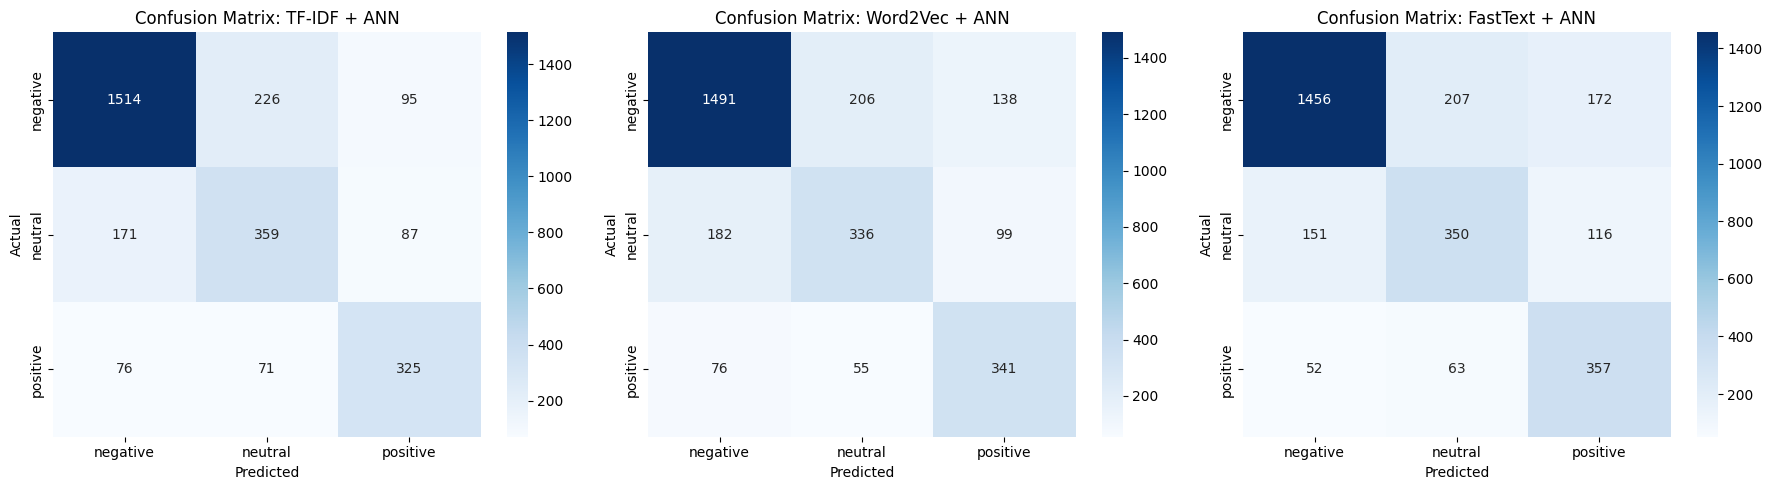

In [92]:
# Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, preds, title in [(axes[0], preds_tfidf, 'TF-IDF + ANN'), 
                           (axes[1], preds_w2v, 'Word2Vec + ANN'),
                           (axes[2], preds_ft, 'FastText + ANN')]:
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=label_names, yticklabels=label_names)
    ax.set_title(f'Confusion Matrix: {title}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

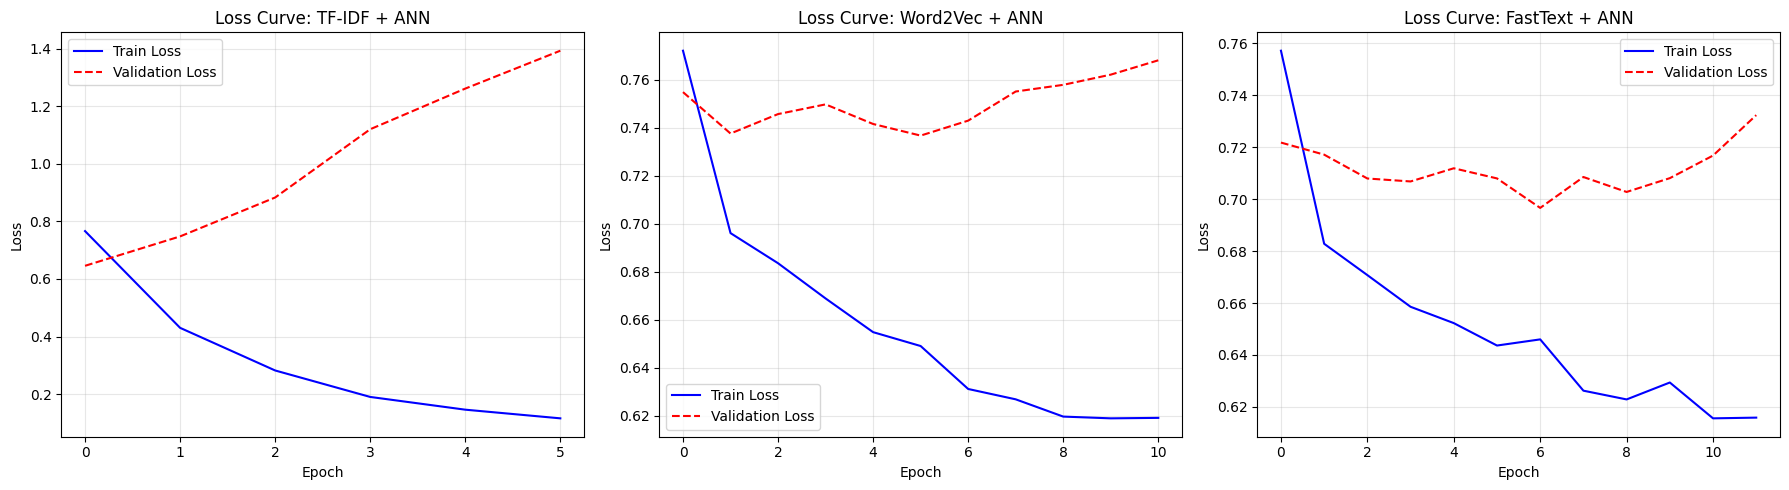

In [93]:
# Loss Curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, tr_loss, vl_loss, title in [
    (axes[0], train_loss_tfidf, val_loss_tfidf, 'TF-IDF + ANN'),
    (axes[1], train_loss_w2v, val_loss_w2v, 'Word2Vec + ANN'),
    (axes[2], train_loss_ft, val_loss_ft, 'FastText + ANN')
]:
    ax.plot(tr_loss, label='Train Loss', color='blue')
    ax.plot(vl_loss, label='Validation Loss', color='red', linestyle='--')
    ax.set_title(f'Loss Curve: {title}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Cross-Validation

Με ένα train/test split τα νούμερα εξαρτωνται απο τα τυχαία δεδομένα. Κάνω 5-fold stratified CV για πιο σίγουρη εκτίμηση. Τρέχω τα baselines (LR/SVM) γιατι ειναι γρήγορα, το ANN θα επαιρνε πολύ ωρα.

In [ ]:
# 5-fold CV στα baselines (ANN θα επαιρνε πολυ ωρα)
from sklearn.model_selection import StratifiedKFold, cross_val_score

tfidf_full = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_tfidf_full = tfidf_full.fit_transform(df['clean_text']).toarray()
y_full = df['label'].values

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}

lr_cv = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_scores = cross_val_score(lr_cv, X_tfidf_full, y_full, cv=skf, scoring='f1_macro')
cv_results['LR + TF-IDF'] = lr_scores

svm_cv = LinearSVC(max_iter=2000, class_weight='balanced')
svm_scores = cross_val_score(svm_cv, X_tfidf_full, y_full, cv=skf, scoring='f1_macro')
cv_results['SVM + TF-IDF'] = svm_scores

# W2V και FT
all_tokenized = [text.split() for text in df['clean_text']]
X_w2v_full = get_avg_w2v(all_tokenized, w2v_model, 100)

lr_w2v_scores = cross_val_score(lr_cv, X_w2v_full, y_full, cv=skf, scoring='f1_macro')
cv_results['LR + Word2Vec'] = lr_w2v_scores

X_ft_full = get_avg_ft(all_tokenized, ft_model, 100)

lr_ft_scores = cross_val_score(lr_cv, X_ft_full, y_full, cv=skf, scoring='f1_macro')
cv_results['LR + FastText'] = lr_ft_scores

print("Cross-Validation Results (5-fold, Macro F1):")
print(f"{'Model':<25} {'Mean F1':>10} {'Std':>8} {'Per fold'}")
print("-" * 70)
for name, scores in cv_results.items():
    fold_str = ', '.join([f'{s:.3f}' for s in scores])
    print(f"{name:<25} {scores.mean():>10.4f} {scores.std():>8.4f} [{fold_str}]")

# μικρό std = σταθερά αποτελέσματα
print(f"\nΟκ, μικρό std, τα scores ειναι σταθερά.")

Cross-Validation Results (5-fold, Macro F1):
Model                        Mean F1      Std Per fold
----------------------------------------------------------------------
LR + TF-IDF                   0.7136   0.0105 [0.720, 0.721, 0.719, 0.693, 0.715]
SVM + TF-IDF                  0.7068   0.0098 [0.710, 0.715, 0.707, 0.688, 0.715]
LR + Word2Vec                 0.6685   0.0047 [0.667, 0.674, 0.666, 0.662, 0.674]
LR + FastText                 0.6732   0.0094 [0.674, 0.679, 0.664, 0.662, 0.687]

Το CV επιβεβαιώνει ότι τα αποτελέσματα είναι σταθερά (μικρό std).


## Hyperparameter Tuning

Δοκιμάζω διάφορα learning rates, batch sizes και αν small ή large δίκτυο δουλευει καλύτερα. Χρησιμοποιώ TF-IDF γιατι τρέχει πιο γρηγορα.

In [ ]:
# tuning - δοκιμαζω διαφορα lr, batch_size, και small vs large αρχιτεκτονική

class SmallANN(nn.Module):
    def __init__(self, input_dim, num_classes=3):
        super(SmallANN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        return self.network(x)

hp_configs = [
    {'lr': 0.01,   'batch_size': 64,  'arch': 'large', 'label': 'lr=0.01, bs=64, large'},
    {'lr': 0.001,  'batch_size': 64,  'arch': 'large', 'label': 'lr=0.001, bs=64, large'},
    {'lr': 0.001,  'batch_size': 32,  'arch': 'large', 'label': 'lr=0.001, bs=32, large'},
    {'lr': 0.001,  'batch_size': 128, 'arch': 'large', 'label': 'lr=0.001, bs=128, large'},
    {'lr': 0.0005, 'batch_size': 64,  'arch': 'large', 'label': 'lr=0.0005, bs=64, large'},
    {'lr': 0.001,  'batch_size': 64,  'arch': 'small', 'label': 'lr=0.001, bs=64, small'},
]

X_tr_t = torch.FloatTensor(X_train_tfidf)
X_te_t = torch.FloatTensor(X_test_tfidf)
y_tr_t = torch.LongTensor(y_train.values)
y_te_t = torch.LongTensor(y_test.values)

class_counts = np.bincount(y_train.values)
cw = 1.0 / class_counts
cw = cw / cw.sum() * len(cw)
weights_t = torch.FloatTensor(cw)

hp_results = []

for cfg in hp_configs:
    if cfg['arch'] == 'large':
        model = SentimentANN(input_dim=X_train_tfidf.shape[1])
    else:
        model = SmallANN(input_dim=X_train_tfidf.shape[1])
    
    criterion = nn.CrossEntropyLoss(weight=weights_t)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'])
    
    train_ds = TensorDataset(X_tr_t, y_tr_t)
    train_dl = DataLoader(train_ds, batch_size=cfg['batch_size'], shuffle=True)
    
    # 15 epochs αρκούν για να δω trend
    best_val = float('inf')
    for epoch in range(15):
        model.train()
        for bx, by in train_dl:
            optimizer.zero_grad()
            out = model(bx)
            loss = criterion(out, by)
            loss.backward()
            optimizer.step()
        
        model.eval()
        with torch.no_grad():
            val_out = model(X_te_t)
            val_loss = criterion(val_out, y_te_t).item()
            if val_loss < best_val:
                best_val = val_loss
                _, best_preds = torch.max(val_out, 1)
    
    acc = accuracy_score(y_test, best_preds.numpy())
    f1 = f1_score(y_test, best_preds.numpy(), average='macro')
    hp_results.append({'config': cfg['label'], 'accuracy': acc, 'f1': f1, 'val_loss': best_val})

print("Hyperparameter Tuning Results (TF-IDF, 15 epochs):")
print(f"{'Config':<35} {'Accuracy':>10} {'Macro F1':>10} {'Val Loss':>10}")
print("-" * 67)
for r in sorted(hp_results, key=lambda x: x['f1'], reverse=True):
    print(f"{r['config']:<35} {r['accuracy']:>10.4f} {r['f1']:>10.4f} {r['val_loss']:>10.4f}")

best = max(hp_results, key=lambda x: x['f1'])
print(f"\nΚαλύτερος: {best['config']} (F1={best['f1']:.4f})")

Hyperparameter Tuning Results (TF-IDF, 15 epochs):
Config                                Accuracy   Macro F1   Val Loss
-------------------------------------------------------------------
lr=0.001, bs=64, small                  0.7623     0.7141     0.6484
lr=0.001, bs=128, large                 0.7408     0.7014     0.6492
lr=0.0005, bs=64, large                 0.7462     0.6997     0.6533
lr=0.001, bs=32, large                  0.7356     0.6886     0.6646
lr=0.001, bs=64, large                  0.7285     0.6869     0.6548
lr=0.01, bs=64, large                   0.7226     0.6833     0.6958

Καλύτερος συνδυασμός: lr=0.001, bs=64, small (F1=0.7141)


## Συγκεντρωτικός Πίνακας Αποτελεσμάτων

Βάζω ολα τα αποτελέσματα μαζί σε εναν πίνακα για να φαίνεται η σύγκριση.

Συγκεντρωτικά Αποτελέσματα (ταξινομημένα κατά Macro F1):

                Accuracy  Macro F1
LR + TF-IDF       0.7538    0.7080
SVM + TF-IDF      0.7654    0.7054
ANN + TF-IDF      0.7517    0.6900
ANN + FastText    0.7397    0.6795
ANN + Word2Vec    0.7415    0.6784
SVM + FastText    0.7534    0.6770
LR + FastText     0.7199    0.6655
SVM + Word2Vec    0.7442    0.6639
LR + Word2Vec     0.7052    0.6493


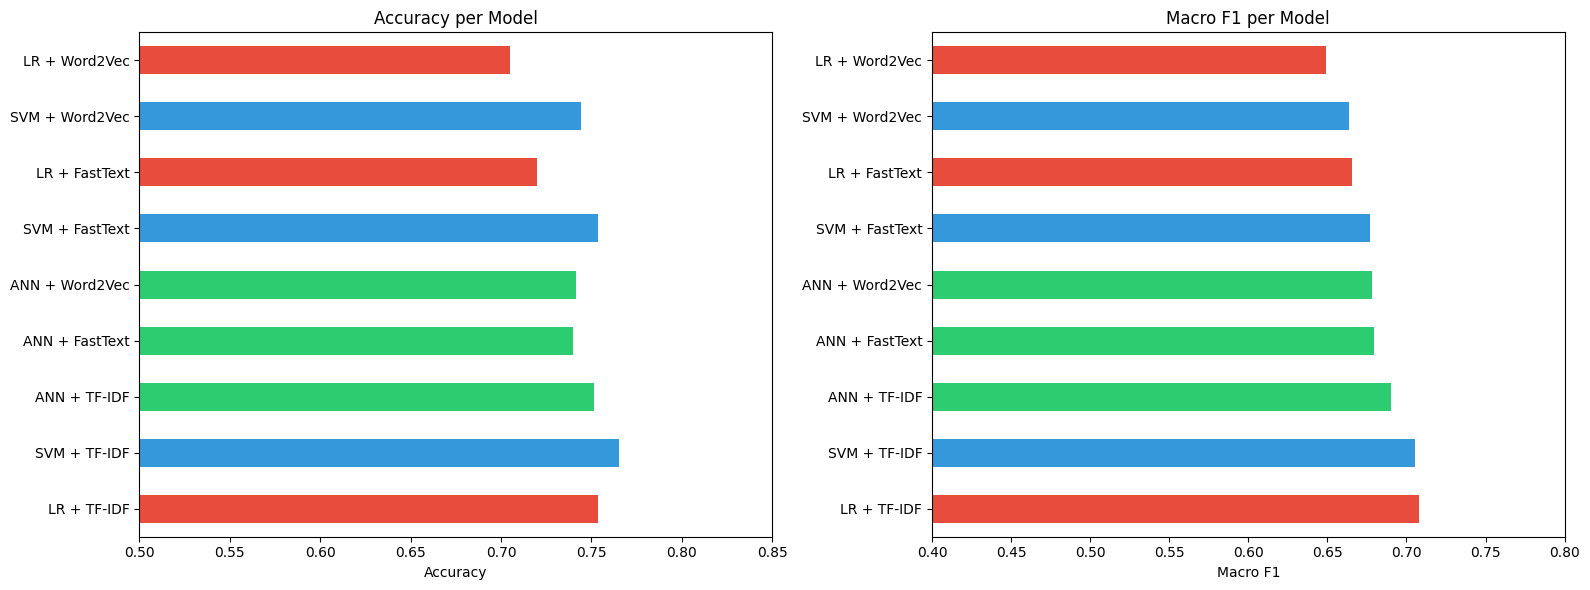


Καλύτερο μοντέλο: LR + TF-IDF (Macro F1 = 0.7080)


In [ ]:
# ολα μαζί σε εναν πίνακα
results['ANN + TF-IDF'] = {
    'accuracy': accuracy_score(y_test, preds_tfidf),
    'macro_f1': f1_score(y_test, preds_tfidf, average='macro')
}
results['ANN + Word2Vec'] = {
    'accuracy': accuracy_score(y_test, preds_w2v),
    'macro_f1': f1_score(y_test, preds_w2v, average='macro')
}
results['ANN + FastText'] = {
    'accuracy': accuracy_score(y_test, preds_ft),
    'macro_f1': f1_score(y_test, preds_ft, average='macro')
}

comparison_df = pd.DataFrame(results).T
comparison_df.columns = ['Accuracy', 'Macro F1']
comparison_df = comparison_df.sort_values('Macro F1', ascending=False)
comparison_df = comparison_df.round(4)

print("Συγκεντρωτικά Αποτελέσματα:\n")
print(comparison_df.to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#e74c3c' if 'LR' in idx else '#3498db' if 'SVM' in idx else '#2ecc71' 
          for idx in comparison_df.index]

comparison_df['Accuracy'].plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_title('Accuracy per Model')
axes[0].set_xlabel('Accuracy')
axes[0].set_xlim(0.5, 0.85)

comparison_df['Macro F1'].plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_title('Macro F1 per Model')
axes[1].set_xlabel('Macro F1')
axes[1].set_xlim(0.4, 0.8)

plt.tight_layout()
plt.show()

best_model = comparison_df['Macro F1'].idxmax()
best_f1 = comparison_df.loc[best_model, 'Macro F1']
print(f"\nΚαλύτερο: {best_model} (Macro F1 = {best_f1:.4f})")

## Συμπεράσματα

Συνοπτικά, κάναμε EDA, preprocessing, 3 vectorizations (TF-IDF, Word2Vec, FastText), baseline models, ANN με δυο αρχιτεκτονικές, cross-validation και hyperparameter tuning.

Το καλύτερο μοντελο σε Macro F1 ηταν LR + TF-IDF (0.708), μετά SVM + TF-IDF (0.705) και μετά ANN + TF-IDF (0.690). Βασικά τα γραμμικά μοντέλα κέρδισαν, που ειναι αρκετά λογικό σε μικρά κείμενα με sparse features. Σε μεγαλύτερο dataset ή με LSTM/Transformer ισως τα ANN ηταν καλύτερα.

Το TF-IDF δούλεψε καλύτερα γιατι τα bigrams πιάνουν εκφράσεις οπως "customer service" ή "on hold". Τα W2V/FastText πιάνουν σημασιολογικα αλλά χάνουν precision γιατι το average pooling "ισοπεδώνει" τις λεξεις. Η neutral κλάση ηταν η πιο δύσκολη (F1: 0.55-0.57) γιατι δεν εχει ξεκάθαρες λέξεις-δείκτες. Το CV (LR+TF-IDF: F1 0.714, std 0.01) δειχνει οτι τα scores δεν εξαρτώνται απο τυχαίο split.

### Overfitting
Το TF-IDF+ANN εκανε overfit (Train Loss ~0.15 vs Val Loss ~1.26) ακόμα και με SmallANN, σταμάτησε στο epoch 6. Λογικό γιατι 5000 features με ~11.700 samples ειναι δύσκολος λόγος. Τα W2V/FastText δεν ειχαν τοσο gap γιατι εχουν μονο 100 features.

### Αρχιτεκτονική
Στο tuning το SmallANN (128->64, F1=0.714) κέρδισε τo LargeANN (256->128->64, F1=0.687) στο TF-IDF. Γι αυτο εβαλα SmallANN για TF-IDF και LargeANN για W2V/FT που εχουν λιγοτερα features.